# Análise de Dados - Gráficos

Neste notebook iremos fazer uma Análise Exploratória dos Dados (EDA) focada no arquivo 'ecommerce_estatistica.csv'.

O objetivo é extrair insights valiosos através de **7 gráficos fundamentais**.

**Analista:** Guilherme Fontoura

**Data:** Maio/2026

---

## 0 · Importação de Bibliotecas e Carga de Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Carrega o arquivo
df = pd.read_csv('ecommerce_estatistica.csv')

print(f'Dataset: {df.shape[0]} produtos × {df.shape[1]} colunas')
df.head(3)

Dataset: 295 produtos × 24 colunas


,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444


## 1 · Histograma — Distribuição das Notas

**Por que `Nota`?**
Notas concentradas em uma faixa estreita (ex.: 4,3–4,7) podem indicar inflação artificial de avaliações. O histograma revela a forma real dessa distribuição — se é gaussiana, assimétrica ou multimodal — e orienta decisões de curadoria de catálogo.

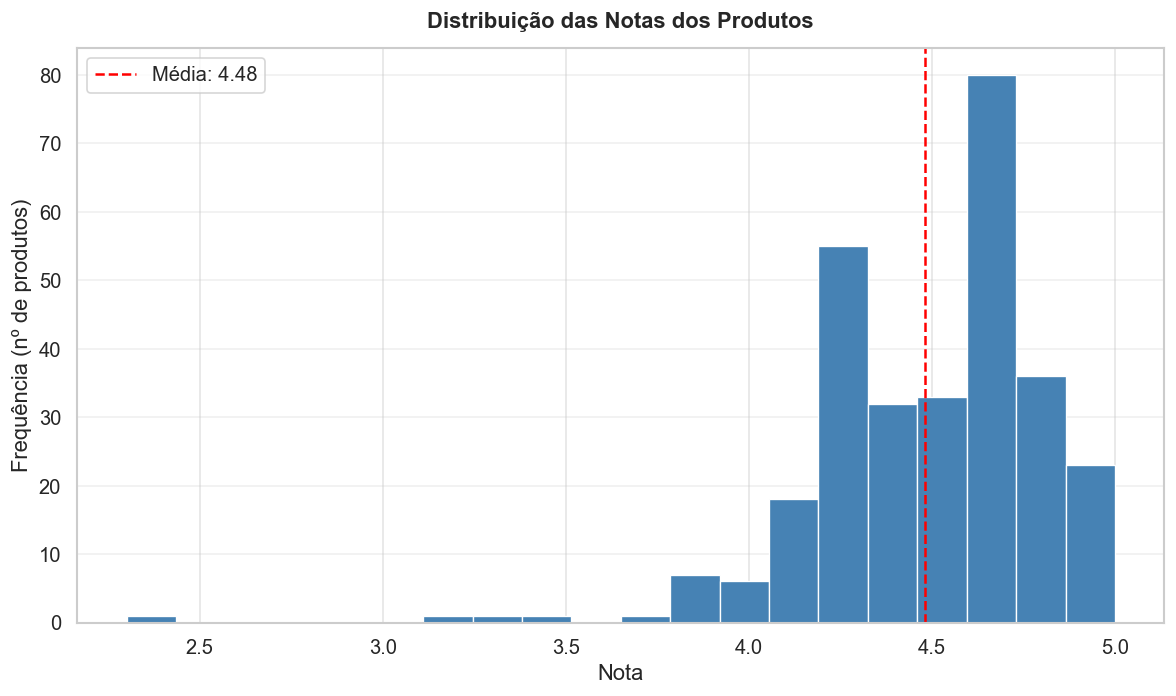

In [2]:
plt.figure(figsize=(10, 6))
plt.hist(df['Nota'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)

media = df['Nota'].mean()
plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')

plt.title('Distribuição das Notas dos Produtos', fontweight='bold', pad=12)
plt.xlabel('Nota')
plt.ylabel('Frequência (nº de produtos)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Insight Estratégico:

A concentração de 80% do catálogo com notas superiores a 4.0 revela uma base de produtos de alta confiabilidade. No entanto, o pico em 4.5 e a escassez de notas 5.0 indicam que, embora o cliente esteja satisfeito, há uma oportunidade de identificar o que impede a 'excelência máxima'. Para o negócio, isso significa um baixo índice de devolução por má qualidade, mas também uma dificuldade em criar produtos 'campeões absolutos' de crítica.

## 2 · Dispersão — Preço vs. Nota

**Por que `Preço vs. Nota`?**
A pergunta central de precificação: *produtos mais caros são melhor avaliados?* Se a nuvem de pontos não mostrar correlação positiva, o e-commerce não pode usar preço como sinal de qualidade — o que muda a estratégia de comunicação com o cliente.

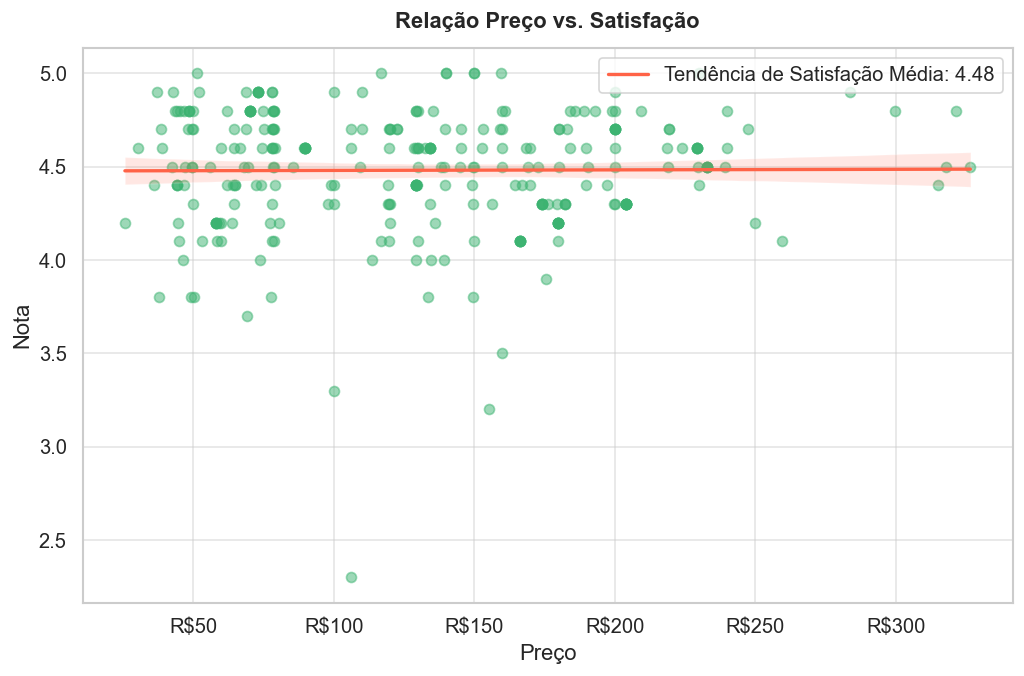

In [3]:
plt.figure(figsize=(10, 6))

sns.regplot(x='Preço', y='Nota', data=df,
            scatter_kws={'alpha': 0.5, 'color': 'mediumseagreen'},
            line_kws={'color': 'tomato', 'linewidth': 2, 'label': f'Tendência de Satisfação Média: {df["Nota"].mean():.2f}'})
plt.title('Relação Preço vs. Satisfação', fontweight='bold', pad=12)
plt.gca().xaxis.set_major_formatter('R${x:,.0f}')
plt.legend(loc='upper right', frameon=True)
plt.show()

Insight Estratégico:

Ao analisarmos a linha de tendência (em destaque vermelho), observamos que ela se mantém praticamente horizontal. Isso prova que, neste e-commerce, **o aumento de preço não é sinônimo de maior qualidade percebida pelo cliente.** Produtos de entrada (mais baratos) possuem o mesmo nível de satisfação (Nota: 4.48) que produtos de luxo. Podemos utilizar isso em campanhas de marketing para reforçar o 'Custo-Benefício', garantindo ao consumidor que ele não precisa pagar mais caro para ter um produto bem avaliado.


## 3 · Mapa de Calor — Correlação entre Variáveis Numéricas

**Por que correlação geral?**
O mapa de calor entrega em uma única imagem todas as relações entre variáveis. Ele responde perguntas como: *desconto alto está associado a mais vendas? Nota e número de avaliações caminham juntos?* É o ponto de partida para qualquer análise exploratória mais profunda.

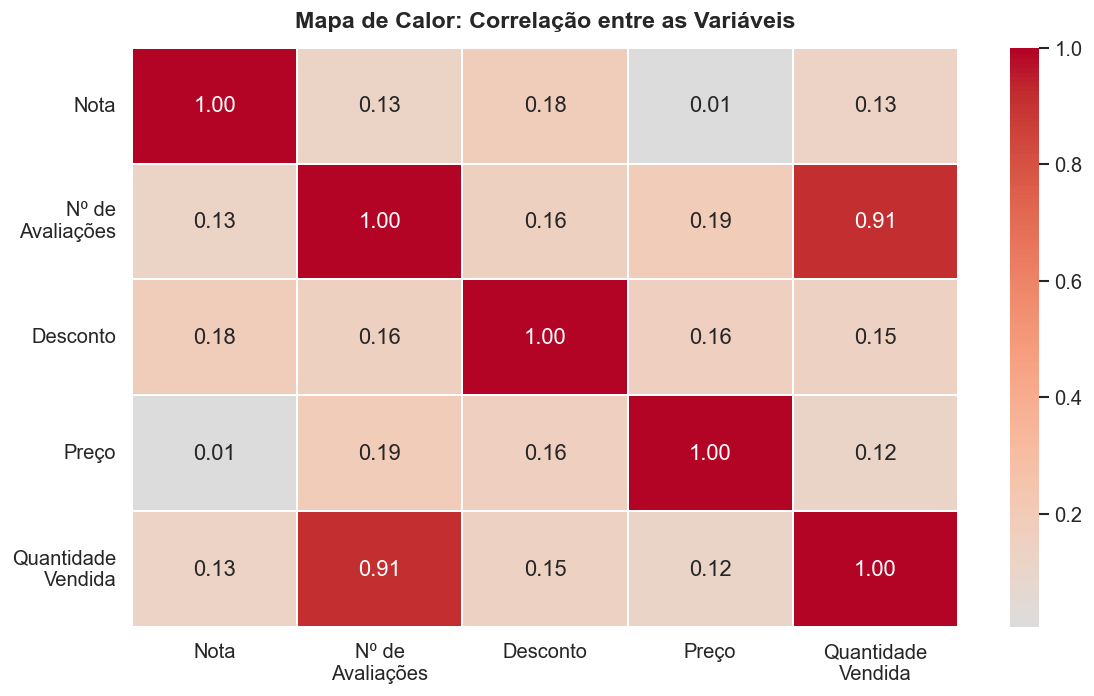

In [4]:
cols_simples = ['Nota', 'N_Avaliações', 'Desconto', 'Preço', 'Qtd_Vendidos_Cod']
cols_renomeadas = {
    'Nota': 'Nota',
    'N_Avaliações': 'Nº de\nAvaliações',
    'Desconto': 'Desconto',
    'Preço': 'Preço',
    'Qtd_Vendidos_Cod': 'Quantidade\nVendida'
}
corr_renomeadas = df[cols_simples].rename(columns=cols_renomeadas).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_renomeadas, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.yticks(rotation=0)
plt.title('Mapa de Calor: Correlação entre as Variáveis', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Insight Estratégico:

O principal ponto de atenção neste gráfico é a fortíssima correlação positiva (0.91) entre o Nº de Avaliações e a Quantidade Vendida, o que prova que a "prova social" é o maior motor de conversão desse E-commerce, superando de longe o impacto do Desconto (0.15). Outro dado crucial para a estratégia de precificação é a correlação quase nula (0.01) entre Preço e Nota, revelando que a satisfação do cliente é independente do valor pago; isso dá segurança para trabalhar margens maiores em produtos premium, já que o preço elevado não inibe a percepção de qualidade do consumidor. Em suma: para vender mais, o foco deve ser incentivar avaliações de clientes, e não necessariamente baixar preços.

## 4 · Barras — Produtos vs. Perfomance por Marca

**Por que `Produtos de uma Marca vs. Performance`?** Identificar concentração de catálogo é essencial para curadoria. Nem sempre marcas com mais produtos vendem mais. Comparar catálogo e vendas ajuda a identificar eficiência comercial, concentração de vendas e possíveis excessos de produtos com baixa conversão.

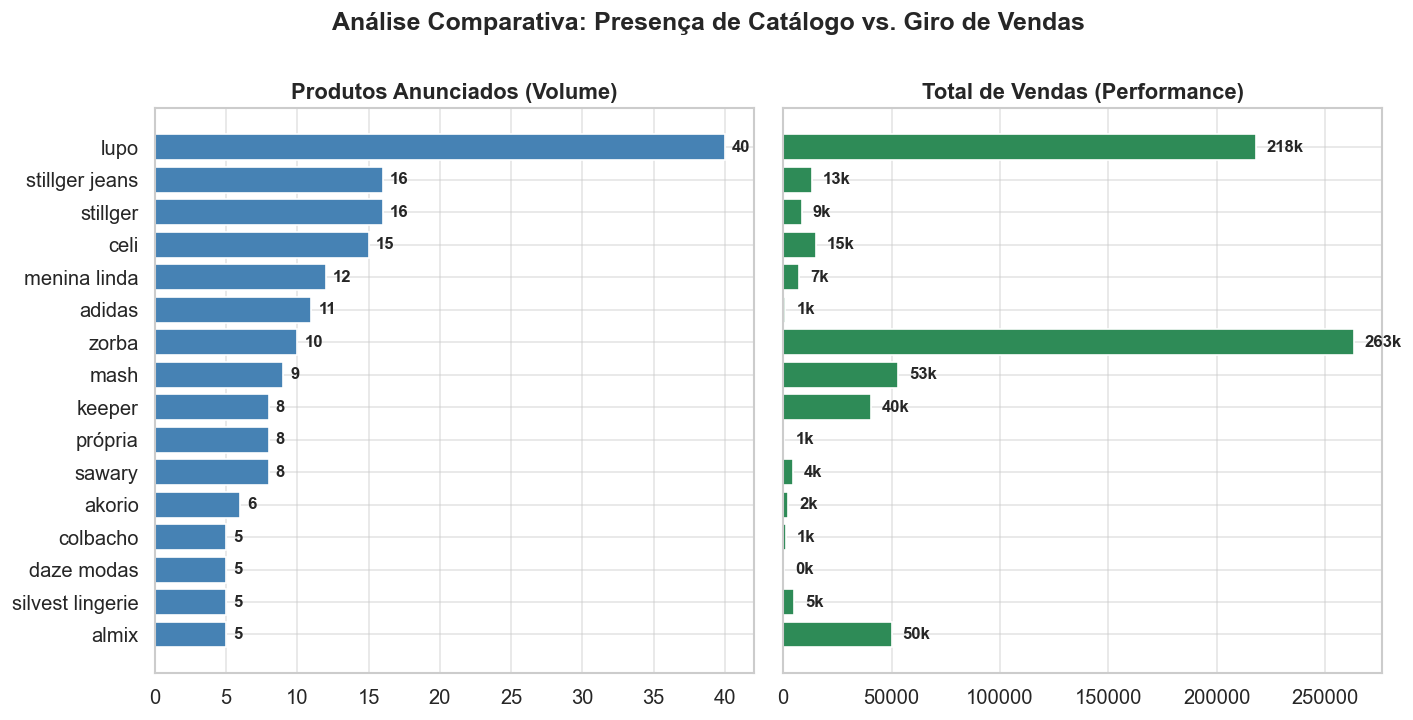

In [5]:
analise = df.groupby('Marca').agg(
    Anunciados=('Marca', 'count'),
    Vendas=('Qtd_Vendidos_Cod', 'sum')
).sort_values('Anunciados', ascending=False).head(16)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax1.barh(analise.index, analise['Anunciados'], color='steelblue')
ax1.set_title('Produtos Anunciados (Volume)', fontweight='bold')
ax1.invert_yaxis()

for i, v in enumerate(analise['Anunciados']):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')

ax2.barh(analise.index, analise['Vendas'], color='seagreen')
ax2.set_title('Total de Vendas (Performance)', fontweight='bold')

for i, v in enumerate(analise['Vendas']):
    ax2.text(v + 5000, i, f'{v/1000:.0f}k', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Análise Comparativa: Presença de Catálogo vs. Giro de Vendas', fontsize=15, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

Insight Estratégico:

O gráfico mostra que volume de catálogo não garante performance. A Zorba possui poucos produtos, mas lidera amplamente em vendas, indicando alta eficiência comercial e forte demanda. Já marcas como Stillger e Adidas apresentam muitos anúncios, porém baixo giro de vendas, sugerindo baixa conversão ou excesso de catálogo. Isso indica que o e-commerce deveria focar menos em quantidade de produtos e mais em estratégias que aumentem conversão e desempenho das marcas mais eficientes.

## 5 · Pizza — Distribuição por Gênero

**Por que `Gênero`?**
O gráfico de pizza mostra de forma imediata para qual público o catálogo está direcionado. Uma desproporção muito grande pode revelar oportunidade de expansão ou risco de catálogo não representativo.

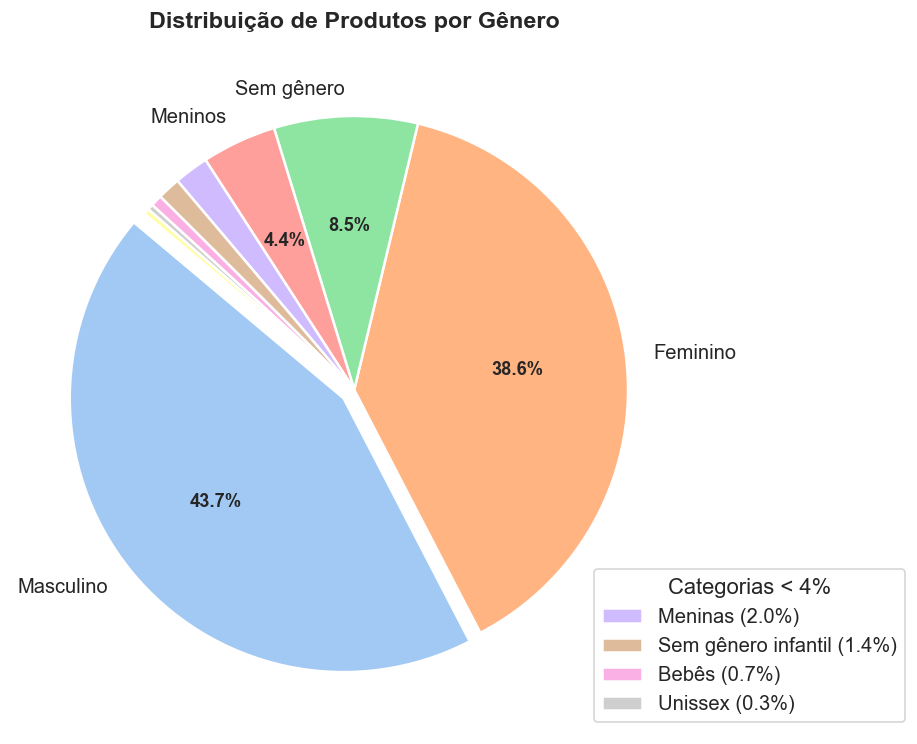

In [6]:
# Contagem dos gêneros
genero_counts = df['Gênero'].value_counts()
# Percentuais
percentuais = genero_counts / genero_counts.sum()

# Mostrar nome apenas >= 4%
labels = [idx if perc >= 0.04 else '' for idx, perc in percentuais.items()]

# Mostrar porcentagem apenas >= 4%
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 4 else ''

# Explode maior fatia
explode = [0.05 if v == genero_counts.max() else 0 for v in genero_counts]

# Cores
colors = sns.color_palette('pastel', len(genero_counts))

# Criar gráfico
fig, ax = plt.subplots(figsize=(8, 10))

wedges, texts, autotexts = ax.pie(
    genero_counts,
    labels=labels,
    autopct=autopct_func,
    startangle=140,
    explode=explode,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

# Estilo das porcentagens
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

# Categorias pequenas (<4%)
categorias_pequenas = [
    f'{genero_counts.index[i]} ({percentuais.iloc[i]*100:.1f}%)'
    for i, perc in enumerate(percentuais)
    if perc < 0.04
    and genero_counts.index[i] != 'roupa para gordinha pluss P ao 52'
]

wedges_pequenas = [wedges[i] for i, perc in enumerate(percentuais) if perc < 0.04]

# Legenda
ax.legend(
    wedges_pequenas,
    categorias_pequenas,
    title='Categorias < 4%',
    loc='lower right',
    bbox_to_anchor=(1.32, 0)
)

# Título
ax.set_title(
    'Distribuição de Produtos por Gênero',
    fontsize=14,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.show()

Insight Estratégico:

O catálogo é fortemente concentrado nos segmentos Masculino (43,7%) e Feminino (38,6%), que juntos representam mais de 80% dos produtos anunciados. Isso mostra que a operação é altamente dependente do público adulto tradicional. Estratégicamente, isso pode indicar duas oportunidades: aprofundar as campanhas mais direcionadas no público principal ou explorar categorias pouco representadas. Destaque para as categorias infantis (Menino, Menina, Bebês) que somadas representam menos 10% do portfólio aparecem como uma clara janela de oportunidade para expansão. E de “Sem gênero” com 8,5% que sugere uma tendência relevante de produtos mais neutros e versáteis no catálogo.

## 6 · Densidade — Distribuição de Preços

**Por que `Preço` com KDE?**
A curva de densidade (KDE) mostra a distribuição contínua, revelando faixas de preço mais populares (moda), cauda longa e possíveis clusters de precificação — informação valiosa para definir faixas de desconto.

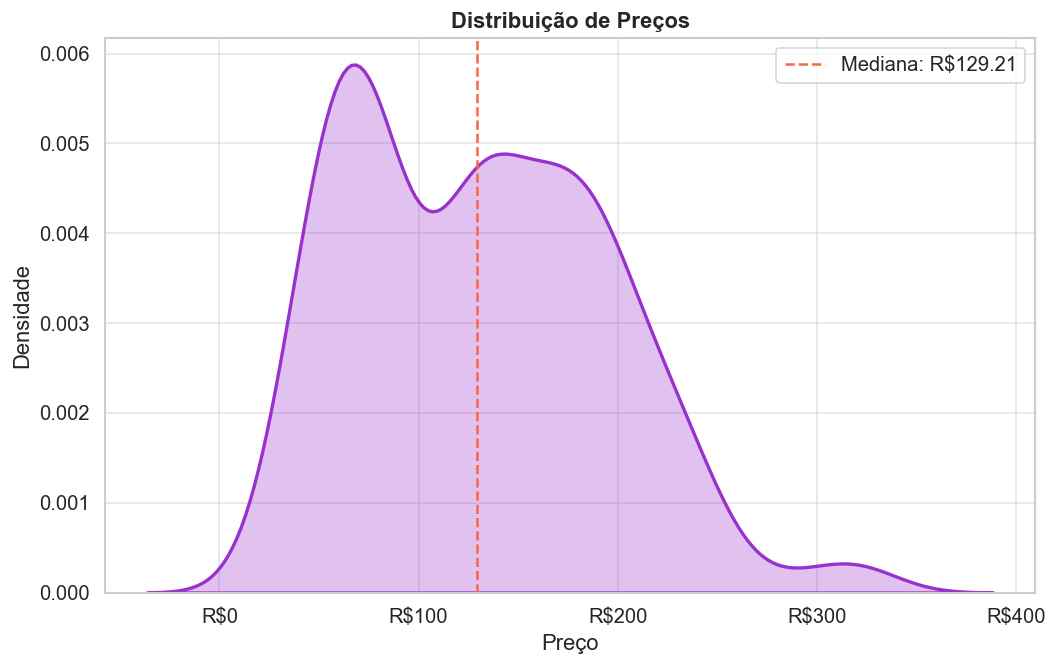

In [7]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df['Preço'], fill=True, color='darkorchid', alpha=0.3, linewidth=2)

mediana = df['Preço'].median()
plt.axvline(mediana, color='tomato', ls='--', label=f'Mediana: R${mediana:.2f}')

plt.title('Distribuição de Preços', fontweight='bold')
plt.xlabel('Preço')
plt.ylabel('Densidade')

plt.gca().xaxis.set_major_formatter('R${x:,.0f}')

plt.legend()
plt.show()

Insight Estratégico:

O e-commerce opera com uma estratégia de precificação bimodal clara: o maior volume de produtos está concentrado na faixa de R$ 60 a R$ 80 (produtos de giro rápido/entrada), seguido por um segundo nicho relevante entre R$ 150 e R$ 180 (produtos intermediários). A mediana de R$ 129,21 atua como uma 'linha divisória' entre o catálogo popular e o catálogo premium. Estrategicamente, existe um vácuo de produtos próximo aos R$ 110, o que pode ser uma oportunidade para lançar itens que façam o 'upsell' do cliente que hoje compra o básico, mas ainda não está disposto a pagar R$ 150.

## 7 · Regressão — Preço vs. Quantidade Vendida

**Por que `Preço vs. Qtd_Vendidos` e não `Desconto vs. N_Avaliações`?**
`Qtd_Vendidos` é a variável de negócio direta — mede o resultado real de vendas. `N_Avaliações` é um proxy indireto e ruidoso (produto novo pode vender muito com poucas avaliações). A regressão aqui responde: *preços mais altos inibem vendas?* A inclinação e o intervalo de confiança orientam diretamente a política de precificação.

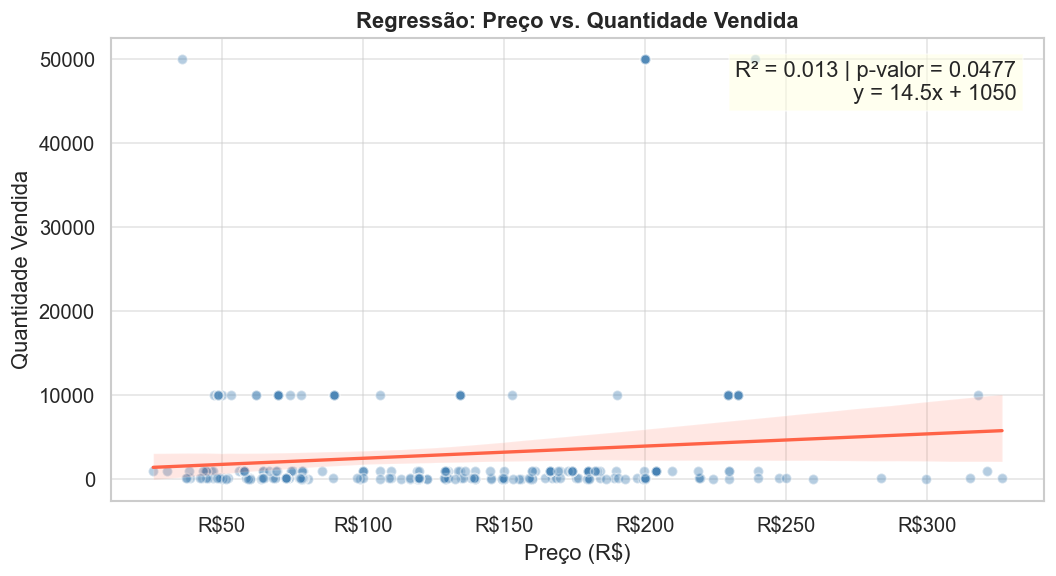

In [8]:
plt.figure(figsize=(9, 5))

# O regplot já pode fazer o scatter e a linha juntos
sns.regplot(x='Preço', y='Qtd_Vendidos_Cod', data=df,
            scatter_kws={'alpha':0.4, 'color':'steelblue', 'edgecolor':'white'},
            line_kws={'color':'tomato', 'linewidth':2}, ci=95)

# Estatísticas (Calculadas uma vez)
slope, intercept, r, p, _ = stats.linregress(df['Preço'], df['Qtd_Vendidos_Cod'])
stats_text = f'R² = {r**2:.3f} | p-valor = {p:.4f}\ny = {slope:.1f}x + {intercept:.0f}'

# Inserindo a caixa de texto de forma simples
plt.text(0.97, 0.95, stats_text, transform=plt.gca().transAxes,
         ha='right', va='top', bbox=dict(facecolor='lightyellow', alpha=0.5))

plt.title('Regressão: Preço vs. Quantidade Vendida', fontweight='bold')
plt.xlabel('Preço (R$)')
plt.ylabel('Quantidade Vendida')
plt.gca().xaxis.set_major_formatter('R${x:,.0f}')

plt.tight_layout()
plt.show()

Insight Estratégico:

A análise de regressão confirma que o e-commerce possui uma baixa sensibilidade ao preço. Com um $R^2$ de apenas 1,3%, fica claro que reduzir preços não é a estratégia mais eficiente para tracionar volume, já que o preço não é o principal driver de decisão do cliente. Além disso, a inclinação positiva da reta sugere que o público valoriza itens de maior valor agregado. Ação: Em vez de entrar em guerras de preços, a empresa deve focar em curadoria de marcas premium e no fortalecimento da prova social (avaliações), onde o retorno sobre o volume de vendas tende a ser muito mais robusto.